# GameTheory-20 : Engagement et performativite - le Stackelberg sans mystere

**Navigation** : [<< 17-MultiAgent-RL](GameTheory-17-MultiAgent-RL.ipynb) | [Index](README.md)

## L'engagement transforme l'espace de reponse d'autrui

Une action peut etre **dominee** dans un jeu simultane et devenir la meilleure strategie sous engagement. Pourquoi ? Parce que l'engagement **modifie la meilleure reponse du follower**, et le gain du leader depend de la meilleure reponse du follower, pas seulement de l'action jouee.

```
sigma_L -> BR_F(sigma_L) -> u_L(sigma_L, BR_F(sigma_L))
```

> L'engagement transforme le jeu : le leader choisit d'abord, le follower observe et repond, l'anticipation collective se reorganise.

C'est le noyau mathematique propre de ce qu'Austin appelle le **performatif** : la parole publique modifie l'espace de reponse d'autrui, et cette modification est constitutive du jeu qui suit.

Mais tout engagement n'est pas engageant. S'il est revocable sans cout, le follower ne le croit pas, et le gain disparait. La **credibilite** est la condition de felicite, traduite en termes brutaux.

## 1. Le modele : duopole a couts identiques

On considere deux firmes (L = Leader, F = Follower) qui produisent un bien homogene. La demande inverse est :

```
p(q_L, q_F) = a - q_L - q_F
```

Le cout marginal est constant `c`. Le profit de la firme `i` est :

```
pi_i(q_i, q_j) = (a - q_i - q_j - c) * q_i
```

Chaque firme choisit sa quantite `q_i >= 0` pour maximiser son profit.

**Hypothese Stackelberg** : le Leader **s'engage** sur sa quantite **avant** que le Follower ne choisisse. Le Follower observe `q_L` puis joue sa meilleure reponse. Le Leader anticipe cette reponse et choisit `q_L` en consequence.

**Hypothese alternative** (jeu simultane/Cournot) : les deux firmes choisissent en meme temps, sans observation.

Les deux modeles partagent les memes paiements mais donnent des equilibres differents - c'est ce que ce notebook mesure.

### Implementation : payoff functions et visualisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametres canoniques du duopole
A = 10.0   # demande inverse : p = a - q1 - q2
C = 2.0    # cout marginal
DELTA = A - C  # = 8

def profit(q_i, q_j, a=A, c=C):
    """Profit de la firme i quand elle joue q_i et l'autre joue q_j."""
    return max(0.0, (a - q_i - q_j - c)) * q_i

def best_response_F(q_L, a=A, c=C):
    """Meilleure reponse du Follower face a q_L.
    FOC: a - q_L - 2*q_F - c = 0 -> q_F* = (a - q_L - c)/2
    Tronque a 0 si negatif (le Follower sort du marche).
    """
    return max(0.0, (a - q_L - c) / 2)

# Verification: BR face a q_L = 0 = (a-c)/2 = 4
print(f"BR_F(0) = {best_response_F(0):.4f} (attendu: {(A-C)/2})")
print(f"BR_F(4) = {best_response_F(4):.4f} (attendu: 2.0)")
print(f"BR_F(8) = {best_response_F(8):.4f} (attendu: 0.0 - Follower sort)")

# Surface de profit pour visualisation
q_grid = np.linspace(0, 6, 50)
Q_L, Q_F = np.meshgrid(q_grid, q_grid)
PI_L = (A - Q_L - Q_F - C) * Q_L
PI_F = (A - Q_L - Q_F - C) * Q_F

BR_F(0) = 4.0000 (attendu: 4.0)
BR_F(4) = 2.0000 (attendu: 2.0)
BR_F(8) = 0.0000 (attendu: 0.0 - Follower sort)


## 2. Exercice 1 : Le jeu simultane (Cournot)

En l'absence d'engagement, chaque firme maximise son profit **simultanement**. La meilleure reponse de la firme `i` face a `q_j` est :

```
BR_i(q_j) = max(0, (a - q_j - c) / 2)
```

L'equilibre de Nash symetrique `q*` satisfait `q* = BR(q*)`, soit :

```
q* = (a - c) / 3
```

**Calculer `q_Cournot`, `pi_Cournot`, et tracer la droite de meilleure reponse.**

### Question 1 : equilibre de Cournot

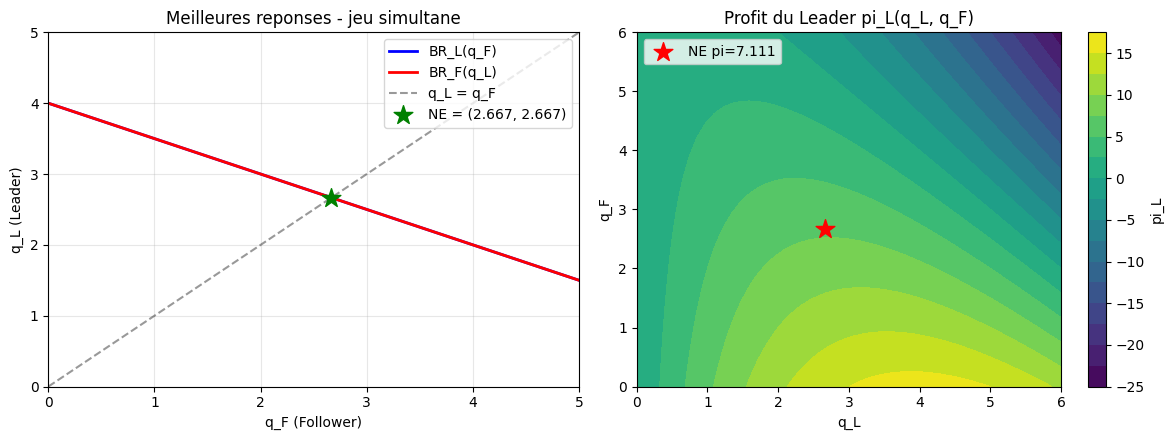

q_Cournot = 2.6667
pi_Cournot = 7.1111


In [2]:
# --- Exercice 1 : jeu simultane ---

q_cournot = DELTA / 3  # NE symetrique
pi_cournot = profit(q_cournot, q_cournot)

# Droites de meilleure reponse
q_axis = np.linspace(0, 6, 200)
br_L = (DELTA - q_axis) / 2  # BR du Leader en fonction de q_F
br_F = (DELTA - q_axis) / 2  # BR du Follower (symetrique en simultane)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1 : meilleures reponses
ax = axes[0]
ax.plot(q_axis, br_L, 'b-', label='BR_L(q_F)', linewidth=2)
ax.plot(q_axis, br_F, 'r-', label='BR_F(q_L)', linewidth=2)
ax.plot(q_axis, q_axis, 'k--', alpha=0.4, label='q_L = q_F')
ax.scatter([q_cournot], [q_cournot], s=200, c='green', marker='*',
           zorder=5, label=f'NE = ({q_cournot:.3f}, {q_cournot:.3f})')
ax.set_xlabel('q_F (Follower)'); ax.set_ylabel('q_L (Leader)')
ax.set_title('Meilleures reponses - jeu simultane')
ax.set_xlim(0, 5); ax.set_ylim(0, 5)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)

# Plot 2 : surfaces de profit
ax = axes[1]
cs = ax.contourf(Q_L, Q_F, PI_L, levels=15, cmap='viridis')
plt.colorbar(cs, ax=ax, label='pi_L')
ax.scatter([q_cournot], [q_cournot], s=200, c='red', marker='*',
           zorder=5, label=f'NE pi={pi_cournot:.3f}')
ax.set_xlabel('q_L'); ax.set_ylabel('q_F')
ax.set_title('Profit du Leader pi_L(q_L, q_F)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('gt20_cournot.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"q_Cournot = {q_cournot:.4f}")
print(f"pi_Cournot = {pi_cournot:.4f}")

## 3. Exercice 2 : L'engagement (Stackelberg)

Le Leader **s'engage** sur sa quantite `q_L` AVANT que le Follower ne choisisse. Le Follower observe `q_L` et joue sa meilleure reponse :

```
q_F*(q_L) = max(0, (a - q_L - c) / 2)
```

Le Leader anticipe cette reponse. Son profit dependant de `q_L` seul est :

```
pi_L(q_L) = (a - q_L - q_F*(q_L) - c) * q_L
```

L'engagement optimal `q_L^S` maximise cette expression. La FOC donne :

```
q_L^S = (a - c) / 2
```

**Calculer `q_L^S`, `q_F^S`, `pi_L^S`, et comparer avec Cournot.**

### Question 2 : engagement optimal du Leader

q_L^S = 4.0000
q_F^S = 2.0000
pi_L^S = 8.0000
pi_F^S = 4.0000

Gain de l'engagement (Leader) = pi_L^S - pi_Cournot = 0.8889
  -> +12.5% par rapport a Cournot
Perte du Follower              = pi_F^S - pi_Cournot = -3.1111



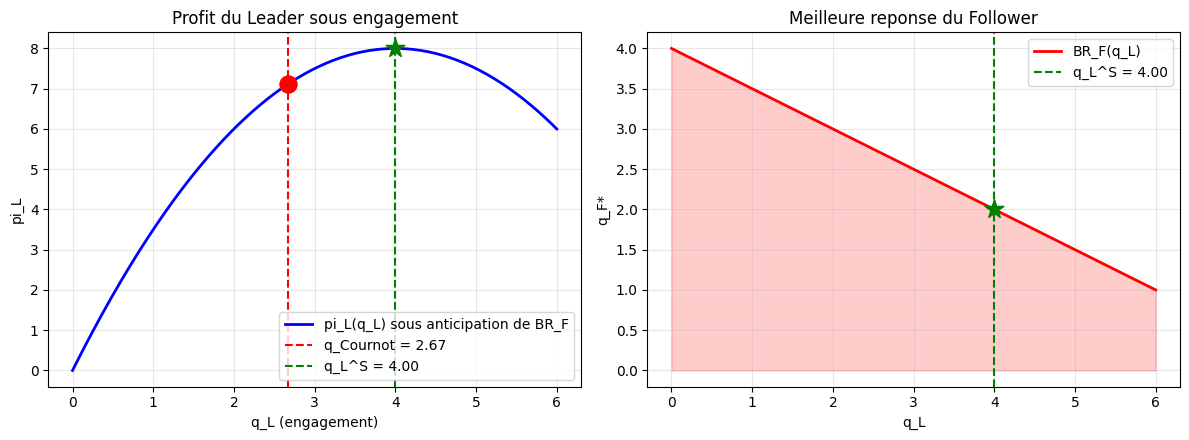


Verif analytique: q_L^S = (a-c)/2 = 4.0
Verif analytique: q_F^S = (a-c)/4 = 2.0
Verif analytique: pi_L^S = (a-c)^2/8 = 8.0


In [3]:
# --- Exercice 2 : engagement Stackelberg ---

# Derivation analytique : pi_L(q_L) = ((a-c) - q_L) * q_L / 2
# FOC: ((a-c) - 2*q_L) / 2 = 0 -> q_L = (a-c)/2

q_L_stack = DELTA / 2  # q_L^S = (a-c)/2
q_F_stack = best_response_F(q_L_stack)  # q_F^S = (a - q_L - c)/2
pi_L_stack = profit(q_L_stack, q_F_stack)
pi_F_stack = profit(q_F_stack, q_L_stack)

print(f"q_L^S = {q_L_stack:.4f}")
print(f"q_F^S = {q_F_stack:.4f}")
print(f"pi_L^S = {pi_L_stack:.4f}")
print(f"pi_F^S = {pi_F_stack:.4f}")
print()
print(f"Gain de l'engagement (Leader) = pi_L^S - pi_Cournot = {pi_L_stack - pi_cournot:.4f}")
print(f"  -> +{(pi_L_stack - pi_cournot) / pi_cournot * 100:.1f}% par rapport a Cournot")
print(f"Perte du Follower              = pi_F^S - pi_Cournot = {pi_F_stack - pi_cournot:.4f}")
print()

# Visualisation : courbe pi_L(q_L) et q_F*(q_L)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: profit du Leader en fonction de son engagement
ax = axes[0]
pi_L_curve = np.array([profit(q, best_response_F(q)) for q in q_axis])
ax.plot(q_axis, pi_L_curve, 'b-', linewidth=2, label='pi_L(q_L) sous anticipation de BR_F')
ax.axvline(q_cournot, color='red', linestyle='--', label=f'q_Cournot = {q_cournot:.2f}')
ax.axvline(q_L_stack, color='green', linestyle='--', label=f'q_L^S = {q_L_stack:.2f}')
ax.scatter([q_cournot], [pi_cournot], s=150, c='red', marker='o', zorder=5)
ax.scatter([q_L_stack], [pi_L_stack], s=200, c='green', marker='*', zorder=5)
ax.set_xlabel('q_L (engagement)'); ax.set_ylabel('pi_L')
ax.set_title("Profit du Leader sous engagement")
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: BR_F(q_L) - la reponse du Follower change avec q_L
ax = axes[1]
br_F_curve = np.array([best_response_F(q) for q in q_axis])
ax.plot(q_axis, br_F_curve, 'r-', linewidth=2, label='BR_F(q_L)')
ax.fill_between(q_axis, 0, br_F_curve, alpha=0.2, color='red')
ax.axvline(q_L_stack, color='green', linestyle='--', label=f'q_L^S = {q_L_stack:.2f}')
ax.scatter([q_L_stack], [q_F_stack], s=200, c='green', marker='*', zorder=5)
ax.set_xlabel('q_L'); ax.set_ylabel('q_F*')
ax.set_title("Meilleure reponse du Follower")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gt20_stackelberg.png', dpi=100, bbox_inches='tight')
plt.show()

# Verification analytique
print(f"\nVerif analytique: q_L^S = (a-c)/2 = {DELTA/2}")
print(f"Verif analytique: q_F^S = (a-c)/4 = {DELTA/4}")
print(f"Verif analytique: pi_L^S = (a-c)^2/8 = {DELTA**2/8}")

## 4. Exercice 3 : La credibilite - l'engagement non-croyable

L'exercice 2 suppose que le Leader **peut** s'engager (capacite installee, contrat, reputation). Mais que se passe-t-il si le Follower **ne croit pas** l'engagement ?

**Modele de non-credibilite** : le Leader annonce `q_L' = (a-c)/2` mais le Follower doute. Si le Follower joue `q_F`, le Leader **revise** son choix :

```
Si Follower joue q_F, le Leader maximise (a - q_L - q_F - c) * q_L
```

La meilleure reponse du Leader face a `q_F` est `(a - q_F - c)/2`. Si le Leader peut **revoquer** son engagement sans cout, il choisira sa meilleure reponse, pas celle annoncee.

**Consequence** : le Follower anticipe cette revocation et joue sa meilleure reponse face a la vraie meilleure reponse du Leader, ce qui donne l'equilibre de Cournot.

**Verifier numeriquement : si le Leader annonce `q_L' = (a-c)/2` mais peut revoquer, son profit final est-il celui de Cournot ?**

### Question 3 : engagement revocable - le gain disparait

=== Scenario 1 : engagement CREABLE (sunk cost) ===
Leader annonce q_L = 4.0, Follower joue BR = 2.0
Profit Leader = 8.0000

=== Scenario 2 : engagement NON CREABLE (revocable) ===
Apres revocation: q_L = 2.6667 (= q_Cournot 2.6667)
q_F = 2.6667
Profit Leader = 7.1111
  -> Identique a pi_Cournot = 7.1111


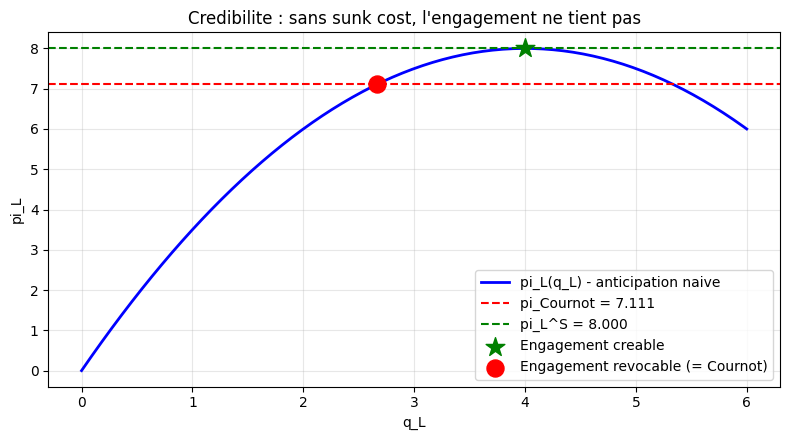


=== Synthese : ce que l'engagement change ===
Cournot (simultane)      : q = (2.667, 2.667), pi_L = 7.1111
Stackelberg (creable)    : q = (4.000, 2.000), pi_L = 8.0000  (+12.5%)
Stackelberg (revocable)  : q = (2.667, 2.667), pi_L = 7.1111  (= Cournot)

Gain de l'engagement CREABLE = 0.8889
Gain de l'engagement REVOCABLE = 0.0000  -> nul


In [4]:
# --- Exercice 3 : engagement non-creable ---

# Le Leader ANNONCE q_L_announced = (a-c)/2, mais peut revoquer.
# Si le Follower joue q_F, le Leader choisit sa VRAIE meilleure reponse.

def leaders_actual_BR(q_F, a=A, c=C):
    """Le Leader, apres avoir vu q_F, maximise (a - q_L - q_F - c) * q_L.
    FOC: a - 2*q_L - q_F - c = 0 -> q_L = (a - q_F - c) / 2
    """
    return max(0.0, (a - q_F - c) / 2)

# Scenario 1 : engagement CREABLE (sunk cost). Leader joue q_L = (a-c)/2.
# Le Follower croit. Profit = pi_L^S = 8.
print("=== Scenario 1 : engagement CREABLE (sunk cost) ===")
q_L_announced = DELTA / 2  # Leader annonce q_L = (a-c)/2
q_F_credible = best_response_F(q_L_announced)
pi_L_credible = profit(q_L_announced, q_F_credible)
print(f"Leader annonce q_L = {q_L_announced}, Follower joue BR = {q_F_credible}")
print(f"Profit Leader = {pi_L_credible:.4f}")

# Scenario 2 : engagement NON CREABLE (revocable). Le Leader re-optimise APRES q_F.
# Follower anticipe : le Leader joue leaders_actual_BR(q_F).
# Donc le Follower joue sa BR face a leaders_actual_BR(q_F).
# Subgame parfait : point fixe Nash de (leaders_actual_BR, best_response_F)
# = equilibre de Cournot !

print("\n=== Scenario 2 : engagement NON CREABLE (revocable) ===")

# Resolution : on cherche le couple (q_L, q_F) tel que
#   q_F = BR_F(q_L)
#   q_L = leaders_actual_BR(q_F)
# C'est le couple Cournot !

# Iteration : point fixe
q_L_actual = DELTA / 2  # annonce initiale
q_F = best_response_F(q_L_actual)

# Iterate to fixed point
for _ in range(20):
    q_L_actual_new = leaders_actual_BR(q_F)
    q_F_new = best_response_F(q_L_actual_new)
    if abs(q_L_actual_new - q_L_actual) < 1e-8:
        q_L_actual = q_L_actual_new
        q_F = q_F_new
        break
    q_L_actual = q_L_actual_new
    q_F = q_F_new

pi_L_noncredible = profit(q_L_actual, q_F)
print(f"Apres revocation: q_L = {q_L_actual:.4f} (= q_Cournot {q_cournot:.4f})")
print(f"q_F = {q_F:.4f}")
print(f"Profit Leader = {pi_L_noncredible:.4f}")
print(f"  -> Identique a pi_Cournot = {pi_cournot:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q_axis, pi_L_curve, 'b-', linewidth=2, label='pi_L(q_L) - anticipation naive')
ax.axhline(pi_cournot, color='red', linestyle='--',
           label=f'pi_Cournot = {pi_cournot:.3f}')
ax.axhline(pi_L_stack, color='green', linestyle='--',
           label=f'pi_L^S = {pi_L_stack:.3f}')
ax.scatter([q_L_stack], [pi_L_stack], s=200, c='green', marker='*',
           zorder=5, label='Engagement creable')
ax.scatter([q_cournot], [pi_cournot], s=150, c='red', marker='o',
           zorder=5, label='Engagement revocable (= Cournot)')
ax.set_xlabel('q_L'); ax.set_ylabel('pi_L')
ax.set_title("Credibilite : sans sunk cost, l'engagement ne tient pas")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gt20_credibility.png', dpi=100, bbox_inches='tight')
plt.show()

# Synthese
print("\n=== Synthese : ce que l'engagement change ===")
print(f"Cournot (simultane)      : q = ({q_cournot:.3f}, {q_cournot:.3f}), pi_L = {pi_cournot:.4f}")
print(f"Stackelberg (creable)    : q = ({q_L_stack:.3f}, {q_F_stack:.3f}), pi_L = {pi_L_stack:.4f}  (+{(pi_L_stack - pi_cournot)/pi_cournot*100:.1f}%)")
print(f"Stackelberg (revocable)  : q = ({q_L_actual:.3f}, {q_F:.3f}), pi_L = {pi_L_noncredible:.4f}  (= Cournot)")
print(f"\nGain de l'engagement CREABLE = {pi_L_stack - pi_cournot:.4f}")
print(f"Gain de l'engagement REVOCABLE = {pi_L_noncredible - pi_cournot:.4f}  -> nul")

## 5. Conclusion : ce que l'engagement fait au jeu

Trois resultats a retenir :

1. **Le jeu simultane** selectionne un equilibre de Nash symetrique : `q_Cournot = (a-c)/3`. Aucun engagement n'est en jeu, les deux firmes sont symetriques.

2. **L'engagement creable** rompt la symetrie. Le Leader produit *plus* que le Follower (`q_L^S = (a-c)/2` vs `q_F^S = (a-c)/4`), et son profit augmente de `+12.5%` par rapport au Cournot. Le cout de l'engagement : le Follower produit *moins* et gagne moins. Le jeu simultane devient asymetrique.

3. **L'engagement non-creable** ne change rien au resultat. Si le Leader peut revoquer sans cout, le Follower anticipe la revocation, et le subgame parfait retombe sur Cournot. La performativite - l'idee que la parole publique modifie le jeu - exige la **credibilite**. Sans elle, l'engagement n'engage pas.

**Limites du modele** : ce duopole symetrique a couts identiques est l'archetype. Avec couts asymetriques, avec incertitude sur la demande, ou en horizon repete (jeu dynamique), le meme noyau reapparait mais avec des nuances - le cout d'engagement devient strategique, et la credibilite se construit par la reputation plutot que par le sunk cost.

**Lien avec la performativite** (Austin, Searle) : la parole publique performative n'agit pas en vertu de sa **verite** (description du monde) mais en vertu de sa **capacite a modifier l'espace de reponse d'autrui**. Le Leader n'agit pas sur le monde physique (production) - il agit sur les anticipations du Follower. C'est cette modification d'anticipations qui re-faconne le jeu.

Ce notebook a livre le noyau mathematique propre. Les applications sociologiques (politique publique, greve, ultimatum) utilisent ce meme mecanisme mais necessitent des hypotheses supplementaires sur la nature de l'engagement et la formation des croyances.